# Activation Functions

## Learning Objectives

1. **State** the definitions and formulas for Sigmoid, Tanh, Softmax, ReLU, Leaky ReLU, and ELU
2. **Compute** the derivative of each activation and explain its role in backpropagation
3. **Identify** the vanishing-gradient pathology in Sigmoid/Tanh and why ReLU mitigates it
4. **Explain** why Softmax is used in multi-class output layers and derive $\partial \mu_i / \partial a_j$
5. **Plot** each activation and its derivative; compare their saturation and dead-unit behaviour


## Problem Statement

An activation function $\sigma: \mathbb{R} \to \mathbb{R}$ (applied element-wise) is the source of non-linearity in a neural network. Without it, stacking linear layers is equivalent to a single linear transformation.

### Summary Table

| Name | Formula $\sigma(z)$ | Derivative $\sigma'(z)$ | Range | Saturates? |
|---|---|---|---|---|
| **Sigmoid** | $\dfrac{1}{1+e^{-z}}$ | $\sigma(1-\sigma)$ | $(0,1)$ | Yes — for $|z|\!\gg\!0$ |
| **Tanh** | $\dfrac{e^z - e^{-z}}{e^z + e^{-z}}$ | $1 - \tanh^2(z)$ | $(-1,1)$ | Yes |
| **ReLU** | $\max(0, z)$ | $\mathbf{1}[z>0]$ | $[0,\infty)$ | No (positive side) |
| **Leaky ReLU** | $\max(\alpha z, z)$, $\alpha{\ll}1$ | $1$ if $z>0$ else $\alpha$ | $\mathbb{R}$ | No |
| **ELU** | $z$ if $z>0$ else $\alpha(e^z-1)$ | $1$ if $z>0$ else $\sigma(z)+\alpha$ | $(-\alpha,\infty)$ | No |
| **Softmax** | $\mu_i = e^{a_i}/\sum_j e^{a_j}$ | $\mu_i(\delta_{ij}-\mu_j)$ | simplex | N/A (vector) |

### Vanishing Gradient Problem

Sigmoid and Tanh saturate: when $|z| \gg 0$, $\sigma'(z) \approx 0$. In backprop, gradients multiply across layers: $\partial L/\partial a^{(1)} = \prod_l \sigma'(a^{(l)}) \cdot \partial L/\partial a^{(L)}$. If every factor $\sigma'(a^{(l)}) < 0.25$, the product vanishes exponentially with depth.


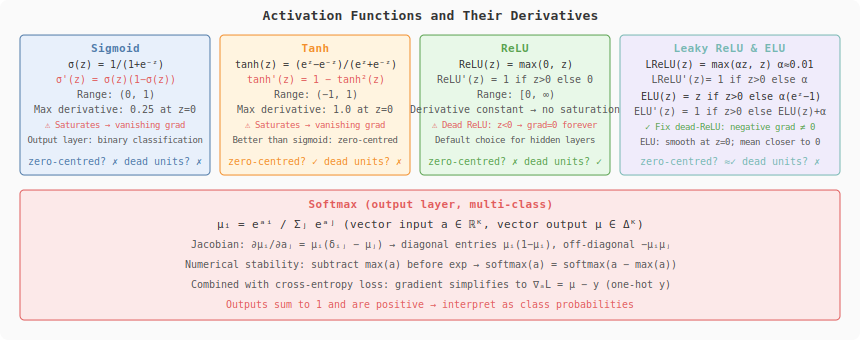

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="340" font-family="monospace" font-size="11">
  <rect width="860" height="340" fill="#fafafa" rx="8"/>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Activation Functions and Their Derivatives</text>

  <!-- Sigmoid -->
  <rect x="20"  y="35" width="190" height="140" rx="4" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="115" y="52" text-anchor="middle" fill="#4e79a7" font-weight="bold">Sigmoid</text>
  <text x="115" y="68" text-anchor="middle" fill="#333" font-size="10">σ(z) = 1/(1+e⁻ᶻ)</text>
  <text x="115" y="83" text-anchor="middle" fill="#e05c5c" font-size="10">σ'(z) = σ(z)(1−σ(z))</text>
  <text x="115" y="98" text-anchor="middle" fill="#555" font-size="10">Range: (0, 1)</text>
  <text x="115" y="113" text-anchor="middle" fill="#555" font-size="10">Max derivative: 0.25 at z=0</text>
  <text x="115" y="128" text-anchor="middle" fill="#e05c5c" font-size="9">⚠ Saturates → vanishing grad</text>
  <text x="115" y="143" text-anchor="middle" fill="#555" font-size="9">Output layer: binary classification</text>
  <text x="115" y="165" text-anchor="middle" fill="#4e79a7" font-size="10">zero-centred? ✗   dead units? ✗</text>

  <!-- Tanh -->
  <rect x="220" y="35" width="190" height="140" rx="4" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="315" y="52" text-anchor="middle" fill="#f28e2b" font-weight="bold">Tanh</text>
  <text x="315" y="68" text-anchor="middle" fill="#333" font-size="10">tanh(z) = (eᶻ−e⁻ᶻ)/(eᶻ+e⁻ᶻ)</text>
  <text x="315" y="83" text-anchor="middle" fill="#e05c5c" font-size="10">tanh'(z) = 1 − tanh²(z)</text>
  <text x="315" y="98" text-anchor="middle" fill="#555" font-size="10">Range: (−1, 1)</text>
  <text x="315" y="113" text-anchor="middle" fill="#555" font-size="10">Max derivative: 1.0 at z=0</text>
  <text x="315" y="128" text-anchor="middle" fill="#e05c5c" font-size="9">⚠ Saturates → vanishing grad</text>
  <text x="315" y="143" text-anchor="middle" fill="#555" font-size="9">Better than sigmoid: zero-centred</text>
  <text x="315" y="165" text-anchor="middle" fill="#f28e2b" font-size="10">zero-centred? ✓   dead units? ✗</text>

  <!-- ReLU -->
  <rect x="420" y="35" width="190" height="140" rx="4" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="515" y="52" text-anchor="middle" fill="#59a14f" font-weight="bold">ReLU</text>
  <text x="515" y="68" text-anchor="middle" fill="#333" font-size="10">ReLU(z) = max(0, z)</text>
  <text x="515" y="83" text-anchor="middle" fill="#555" font-size="10">ReLU'(z) = 1 if z&gt;0  else 0</text>
  <text x="515" y="98" text-anchor="middle" fill="#555" font-size="10">Range: [0, ∞)</text>
  <text x="515" y="113" text-anchor="middle" fill="#555" font-size="10">Derivative constant → no saturation</text>
  <text x="515" y="128" text-anchor="middle" fill="#e05c5c" font-size="9">⚠ Dead ReLU: z&lt;0 → grad=0 forever</text>
  <text x="515" y="143" text-anchor="middle" fill="#555" font-size="9">Default choice for hidden layers</text>
  <text x="515" y="165" text-anchor="middle" fill="#59a14f" font-size="10">zero-centred? ✗   dead units? ✓</text>

  <!-- Leaky ReLU / ELU -->
  <rect x="620" y="35" width="220" height="140" rx="4" fill="#f0ecfb" stroke="#76b7b2"/>
  <text x="730" y="52" text-anchor="middle" fill="#76b7b2" font-weight="bold">Leaky ReLU &amp; ELU</text>
  <text x="730" y="68" text-anchor="middle" fill="#333" font-size="10">LReLU(z) = max(αz, z)  α≈0.01</text>
  <text x="730" y="83" text-anchor="middle" fill="#555" font-size="10">LReLU'(z)= 1 if z&gt;0  else α</text>
  <text x="730" y="100" text-anchor="middle" fill="#333" font-size="10">ELU(z) = z if z&gt;0 else α(eᶻ−1)</text>
  <text x="730" y="115" text-anchor="middle" fill="#555" font-size="10">ELU'(z) = 1 if z&gt;0 else ELU(z)+α</text>
  <text x="730" y="130" text-anchor="middle" fill="#59a14f" font-size="9">✓ Fix dead-ReLU: negative grad ≠ 0</text>
  <text x="730" y="145" text-anchor="middle" fill="#555" font-size="9">ELU: smooth at z=0; mean closer to 0</text>
  <text x="730" y="165" text-anchor="middle" fill="#76b7b2" font-size="10">zero-centred? ≈✓   dead units? ✗</text>

  <!-- Softmax -->
  <rect x="20" y="190" width="820" height="130" rx="4" fill="#fce9e9" stroke="#e05c5c"/>
  <text x="430" y="208" text-anchor="middle" fill="#e05c5c" font-weight="bold">Softmax (output layer, multi-class)</text>
  <text x="430" y="228" text-anchor="middle" fill="#333" font-size="11">μᵢ = eᵃⁱ / Σⱼ eᵃʲ     (vector input a ∈ ℝᴷ, vector output μ ∈ Δᴷ)</text>
  <text x="430" y="248" text-anchor="middle" fill="#555" font-size="10">Jacobian: ∂μᵢ/∂aⱼ = μᵢ(δᵢⱼ − μⱼ)  →  diagonal entries μᵢ(1−μᵢ), off-diagonal −μᵢμⱼ</text>
  <text x="430" y="268" text-anchor="middle" fill="#555" font-size="10">Numerical stability: subtract max(a) before exp  →  softmax(a) = softmax(a − max(a))</text>
  <text x="430" y="288" text-anchor="middle" fill="#555" font-size="10">Combined with cross-entropy loss: gradient simplifies to ∇ₐL = μ − y  (one-hot y)</text>
  <text x="430" y="308" text-anchor="middle" fill="#e05c5c" font-size="10">Outputs sum to 1 and are positive → interpret as class probabilities</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Sigmoid
$$\sigma(z) = \frac{1}{1+e^{-z}}$$
$$\sigma'(z) = \frac{e^{-z}}{(1+e^{-z})^2} = \sigma(z)\bigl(1-\sigma(z)\bigr)$$

Maximum value of $\sigma'$ is $0.25$ at $z=0$. For $|z| > 4$, $\sigma' < 0.02$ — gradients effectively vanish in deep networks.

### Tanh
$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} = 2\sigma(2z) - 1$$
$$\tanh'(z) = 1 - \tanh^2(z)$$

Zero-centred (unlike sigmoid), so gradient updates are symmetric. Still saturates.

### ReLU
$$\text{ReLU}(z) = \max(0,z)$$
$$\text{ReLU}'(z) = \mathbf{1}[z > 0]$$

For $z > 0$, derivative is exactly 1 — no saturation, cheap to compute. **Dead ReLU**: if a unit's pre-activation is always $\leq 0$ (e.g., after a large negative gradient update), its gradient is permanently 0.

### Leaky ReLU
$$\text{LReLU}(z) = \max(\alpha z,\, z), \quad \alpha \in (0,1)$$

Fixes dead ReLU: negative side has gradient $\alpha \neq 0$. Typical $\alpha = 0.01$.

### ELU (Exponential Linear Unit)
$$\text{ELU}(z) = \begin{cases} z & z > 0 \\ \alpha(e^z - 1) & z \leq 0 \end{cases}$$

Smooth at $z=0$ (unlike ReLU/LReLU), mean activations closer to zero, faster convergence in practice.

### Softmax and Its Jacobian

$$\mu_i = \frac{e^{a_i}}{\sum_{j=1}^K e^{a_j}}$$

$$\frac{\partial \mu_i}{\partial a_j} = \mu_i(\delta_{ij} - \mu_j) = \begin{cases} \mu_i(1-\mu_i) & i = j \\ -\mu_i\mu_j & i \neq j \end{cases}$$

When combined with cross-entropy loss $L = -\sum_i y_i \log \mu_i$ (one-hot $\mathbf{y}$), the combined gradient is simply:
$$\frac{\partial L}{\partial \mathbf{a}} = \boldsymbol{\mu} - \mathbf{y}$$


In [2]:
import numpy as np

# ── Activation functions and derivatives ─────────────────────────────────────

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh_act(z):
    return np.tanh(z)

def tanh_prime(z):
    return 1.0 - np.tanh(z)**2

def relu(z):
    return np.maximum(0, z)

def relu_prime(z):
    return (z > 0).astype(float)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_prime(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha)

def elu(z, alpha=1.0):
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

def elu_prime(z, alpha=1.0):
    return np.where(z > 0, 1.0, elu(z, alpha) + alpha)

def softmax(a):
    # numerically stable
    e = np.exp(a - a.max())
    return e / e.sum()

def softmax_jacobian(a):
    mu = softmax(a)
    return np.diag(mu) - np.outer(mu, mu)


# ── Verify softmax gradient against numerical differentiation ─────────────────
rng = np.random.default_rng(42)
a   = rng.standard_normal(5)
J_analytical = softmax_jacobian(a)
eps = 1e-5
J_numerical  = np.zeros((5, 5))
for j in range(5):
    a_plus = a.copy(); a_plus[j] += eps
    a_minus = a.copy(); a_minus[j] -= eps
    J_numerical[:, j] = (softmax(a_plus) - softmax(a_minus)) / (2*eps)

print("Softmax Jacobian max absolute error (analytical vs numerical):",
      np.abs(J_analytical - J_numerical).max())

# ── Vanishing gradient demo: product of sigmoid derivatives across L layers ───
print("\nGradient magnitude through L sigmoid layers (initial grad = 1.0):")
for L in [1, 4, 8, 16, 32]:
    # Worst case: z=0 → σ'=0.25
    grad = 0.25 ** L
    print(f"  L={L:2d}: gradient = {grad:.2e}")

print("\nGradient magnitude through L ReLU layers (initial grad = 1.0):")
for L in [1, 4, 8, 16, 32]:
    grad = 1.0 ** L  # derivative=1 for positive inputs
    print(f"  L={L:2d}: gradient = {grad:.2e}  (constant!)")


Softmax Jacobian max absolute error (analytical vs numerical): 3.1478153417197063e-12

Gradient magnitude through L sigmoid layers (initial grad = 1.0):
  L= 1: gradient = 2.50e-01
  L= 4: gradient = 3.91e-03
  L= 8: gradient = 1.53e-05
  L=16: gradient = 2.33e-10
  L=32: gradient = 5.42e-20

Gradient magnitude through L ReLU layers (initial grad = 1.0):
  L= 1: gradient = 1.00e+00  (constant!)
  L= 4: gradient = 1.00e+00  (constant!)
  L= 8: gradient = 1.00e+00  (constant!)
  L=16: gradient = 1.00e+00  (constant!)
  L=32: gradient = 1.00e+00  (constant!)


In [3]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 400)

functions = [
    ('Sigmoid',     sigmoid(z),        sigmoid_prime(z),     '#4e79a7'),
    ('Tanh',        tanh_act(z),       tanh_prime(z),        '#f28e2b'),
    ('ReLU',        relu(z),           relu_prime(z),        '#59a14f'),
    ('Leaky ReLU',  leaky_relu(z),     leaky_relu_prime(z),  '#76b7b2'),
    ('ELU',         elu(z),            elu_prime(z),         '#e05c5c'),
]

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle('Activation Functions (top) and Their Derivatives (bottom)', fontsize=12)

for col, (name, act, deriv, color) in enumerate(functions):
    ax = axes[0, col]
    ax.plot(z, act, color=color, lw=2)
    ax.axhline(0, color='#999', lw=0.8, ls='--')
    ax.axvline(0, color='#999', lw=0.8, ls='--')
    ax.set_title(name, fontsize=10)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-1.5, 3.5)
    ax.set_xlabel('z', fontsize=8)
    ax.set_ylabel('σ(z)', fontsize=8)

    ax2 = axes[1, col]
    ax2.plot(z, deriv, color=color, lw=2, linestyle='--')
    ax2.axhline(0, color='#999', lw=0.8, ls='--')
    ax2.axvline(0, color='#999', lw=0.8, ls='--')
    ax2.set_xlim(-5, 5)
    ax2.set_ylim(-0.1, 1.3)
    ax2.set_xlabel('z', fontsize=8)
    ax2.set_ylabel("σ'(z)", fontsize=8)

fig.tight_layout()
plt.savefig('activation_functions.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure saved.")


Figure saved.


/tmp/ipykernel_305554/3568893879.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
